<a href="https://colab.research.google.com/github/safoura-banihashemi/predicting-online-news-popularity/blob/main/Predicting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
!pip install pyspark

In [ ]:
import pyspark
from pyspark.sql import SparkSession

print("Creating Spark Session")
print("═"*60)

spark = (SparkSession.builder
         .appName("OnlineNewsPopularity")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark {spark.version}")

Creating Spark Session
════════════════════════════════════════════════════════════
Spark 4.0.2


## Dataset

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
online_news_popularity = fetch_ucirepo(id=332)

# data (as pandas dataframes)
X = online_news_popularity.data.features
y = online_news_popularity.data.targets

print(f"The number of samples: {X.shape[0]}")
print(f"The number of features: {X.shape[1]}")

The number of samples: 39644
The number of features: 58


In [ ]:
# Show first rows of features
print("Features Sample:")
print(X.head(1))

Features Sample:
   n_tokens_title  n_tokens_content  n_unique_tokens  n_non_stop_words  \
0            12.0             219.0         0.663594               1.0   

   n_non_stop_unique_tokens  num_hrefs  num_self_hrefs  num_imgs  num_videos  \
0                  0.815385        4.0             2.0       1.0         0.0   

   average_token_length  ...  avg_positive_polarity  min_positive_polarity  \
0              4.680365  ...               0.378636                    0.1   

   max_positive_polarity  avg_negative_polarity  min_negative_polarity  \
0                    0.7                  -0.35                   -0.6   

   max_negative_polarity  title_subjectivity  title_sentiment_polarity  \
0                   -0.2                 0.5                   -0.1875   

   abs_title_subjectivity  abs_title_sentiment_polarity  
0                     0.0                        0.1875  

[1 rows x 58 columns]


In [ ]:
# Show the first 5 rows of the target (shares)
print("\nTarget Sample:")
print(y.head(1))


Target Sample:
   shares
0     593


In [ ]:
# Print a list of all column names in X
print(X.columns)

Index([' n_tokens_title', ' n_tokens_content', ' n_unique_tokens',
       ' n_non_stop_words', ' n_non_stop_unique_tokens', ' num_hrefs',
       ' num_self_hrefs', ' num_imgs', ' num_videos', ' average_token_length',
       ' num_keywords', ' data_channel_is_lifestyle',
       ' data_channel_is_entertainment', ' data_channel_is_bus',
       ' data_channel_is_socmed', ' data_channel_is_tech',
       ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min',
       ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg',
       ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares',
       ' self_reference_max_shares', ' self_reference_avg_sharess',
       ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday',
       ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday',
       ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02',
       ' LDA_03', ' LDA_04', ' global_subjectivity',
       ' global_sentiment_polarity', ' gl

## Cleaning dataset

In [ ]:
# Get a statistical summary (min, max, mean, standard deviation)
X.describe()

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,...,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,4.548239,...,0.353825,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064
std,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,0.844406,...,0.104542,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000
25%,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,4.478404,...,0.306244,0.050000,0.600000,-0.328383,-0.700000,-0.125000,0.000000,0.000000,0.166667,0.000000
50%,10.000000,409.000000,0.539226,1.000000,0.690476,8.000000,3.000000,1.000000,0.000000,4.664082,...,0.358755,0.100000,0.800000,-0.253333,-0.500000,-0.100000,0.150000,0.000000,0.500000,0.000000
75%,12.000000,716.000000,0.608696,1.000000,0.754630,14.000000,4.000000,4.000000,1.000000,4.854839,...,0.411428,0.100000,1.000000,-0.186905,-0.300000,-0.050000,0.500000,0.150000,0.500000,0.250000
max,23.000000,8474.000000,701.000000,1042.000000,650.000000,304.000000,116.000000,128.000000,91.000000,8.041534,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000


In [ ]:
# Check for null values in each column
print(X.isnull().sum())

# Check for any nulls across the entire dataset at once
print(f"Total missing values: {X.isnull().sum().sum()}")

n_tokens_title                   0
n_tokens_content                 0
n_unique_tokens                  0
n_non_stop_words                 0
n_non_stop_unique_tokens         0
num_hrefs                        0
num_self_hrefs                   0
num_imgs                         0
num_videos                       0
average_token_length             0
num_keywords                     0
data_channel_is_lifestyle        0
data_channel_is_entertainment    0
data_channel_is_bus              0
data_channel_is_socmed           0
data_channel_is_tech             0
data_channel_is_world            0
kw_min_min                       0
kw_max_min                       0
kw_avg_min                       0
kw_min_max                       0
kw_max_max                       0
kw_avg_max                       0
kw_min_avg                       0
kw_max_avg                       0
kw_avg_avg                       0
self_reference_min_shares        0
self_reference_max_shares        0
self_reference_avg_s

In [ ]:
# Check if there are any duplicate rows
print(f"Number of duplicate rows: {X.duplicated().sum()}")

Number of duplicate rows: 0


In [ ]:
# Check for null values in each column
print(y.isnull().sum())

# Check for any nulls across the entire dataset at once
print(f"Total missing values: {y.isnull().sum().sum()}")

shares    0
dtype: int64
Total missing values: 0


## Find best number of share for popularity

In [ ]:
# Calculate the median of the target variable
median_shares = y['shares'].median()
print(f"The median number of shares is: {median_shares}")

KeyError: 'shares'

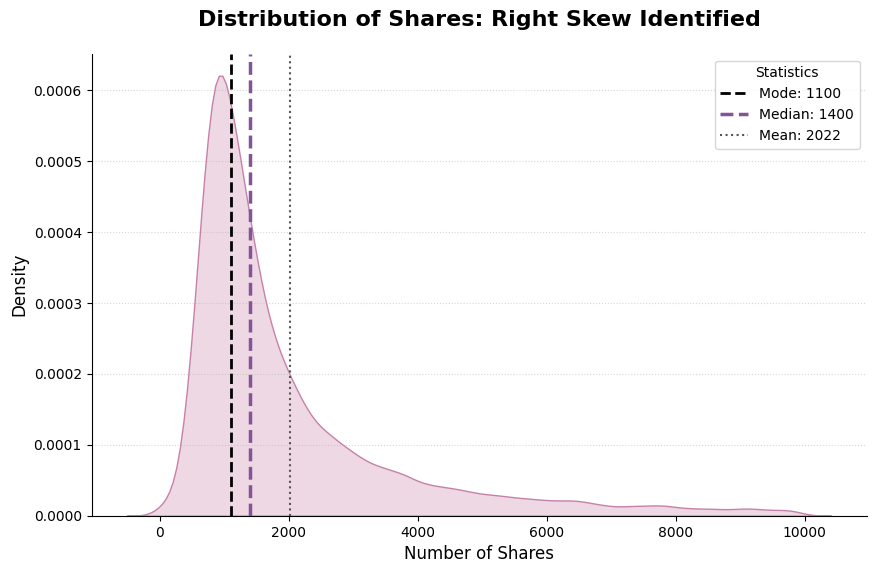

In [ ]:
# Ensure column names are clean (required if you haven't run the strip() fix yet)
y.columns = y.columns.str.strip()

# 1. Filter out extreme outliers (<10k shares) to focus on the main distribution
filtered_y = y[y['shares'] < 10000]['shares']

# 2. Calculate the "Fancy" statistical points
mean_val = filtered_y.mean()
median_val = filtered_y.median() # This should be ~1400
mode_val = filtered_y.mode()[0]  # Take the first mode if multiple exist

# 3. Initialize the plot
fig, ax = plt.subplots(figsize=(10, 6))

# 4. Generate the Smooth Curve (KDE) with Pink Fill (matching image_3.png style)
sns.kdeplot(filtered_y, color="#C781A8", fill=True, alpha=0.3, bw_adjust=0.8)

# 5. Add clear, vertical dashed lines for statistical points
# Mode line (Black, thick)
ax.axvline(mode_val, color='black', linestyle='--', linewidth=2, label=f'Mode: {mode_val:.0f}')
# Median line (Purple, thick - matching your 1400 target threshold)
ax.axvline(median_val, color='#835496', linestyle='--', linewidth=2.5, label=f'Median: {median_val:.0f}')
# Mean line (Dark grey, thin)
ax.axvline(mean_val, color='#555555', linestyle=':', linewidth=1.5, label=f'Mean: {mean_val:.0f}')

# 6. Fancy Formatting & Labels
ax.set_title("Distribution of Shares: Right Skew Identified", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Number of Shares", fontsize=12)
ax.set_ylabel("Density", fontsize=12)

# Set the background to clean white and add subtle gridlines
ax.set_facecolor('white')
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Place the legend
ax.legend(title="Statistics")

# Remove top and right "spines" for a modern, clean look
sns.despine()

plt.show()

## Binary Classification

In [ ]:
# 1. Create the binary label based on the shares in 'y'
# This marks an article as '1' (Popular) if shares > 1400, else '0'
# Clean the column names for both X and y
X.columns = X.columns.str.strip()
y.columns = y.columns.str.strip()

# Now your binary label code will work perfectly!
y_binary = (y['shares'] >= 1400).astype(int)

# 2. Calculate the counts
total = len(y_binary)
popular = y_binary.sum()  # Summing binary 1s gives the count of popular articles
unpopular = total - popular

# 3. Print the distribution results
print("Class distribution:")
print(y_binary.value_counts())

print(f"\nPopular (>=1400 shares): {popular} ({popular/total*100:.2f}%)")
print(f"Unpopular (<1400 shares): {unpopular} ({unpopular/total*100:.2f}%)")

Class distribution:
shares
1    21154
0    18490
Name: count, dtype: int64

Popular (>=1400 shares): 21154 (53.36%)
Unpopular (<1400 shares): 18490 (46.64%)


## Feature selection (RFE)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# 1. Clean names to avoid the KeyError 'shares' from image_0e8d59.png
X.columns = X.columns.str.strip()

# 2. Define the "Base" model (Random Forest is great for RFE)
# We use a small number of trees here to make the recursion faster
estimator = RandomForestClassifier(n_estimators=50, random_state=42)

# 3. Create the RFE selector
# Set n_features_to_select to 10 (your friend's choice) or 20 (yours)
selector = RFE(estimator, n_features_to_select=20, step=1)

# 4. Fit RFE
# Use y_binary (the 0/1 labels) we created earlier
selector = selector.fit(X, y_binary)

# 5. See the results
selected_features = X.columns[selector.support_].tolist()

print(f"Top {len(selected_features)} Features selected by RFE:")
for i, feat in enumerate(selected_features):
    print(f"{i+1}. {feat}")

Top 20 Features selected by RFE:
1. n_tokens_content
2. n_unique_tokens
3. n_non_stop_unique_tokens
4. average_token_length
5. kw_max_min
6. kw_avg_min
7. kw_avg_max
8. kw_max_avg
9. kw_avg_avg
10. self_reference_min_shares
11. self_reference_avg_sharess
12. LDA_00
13. LDA_01
14. LDA_02
15. LDA_03
16. LDA_04
17. global_subjectivity
18. global_sentiment_polarity
19. global_rate_positive_words
20. avg_positive_polarity


Accuracy with 5 features: 0.5814
Accuracy with 10 features: 0.6161
Accuracy with 15 features: 0.6245
Accuracy with 20 features: 0.6242
Accuracy with 25 features: 0.6285
Accuracy with 30 features: 0.6281


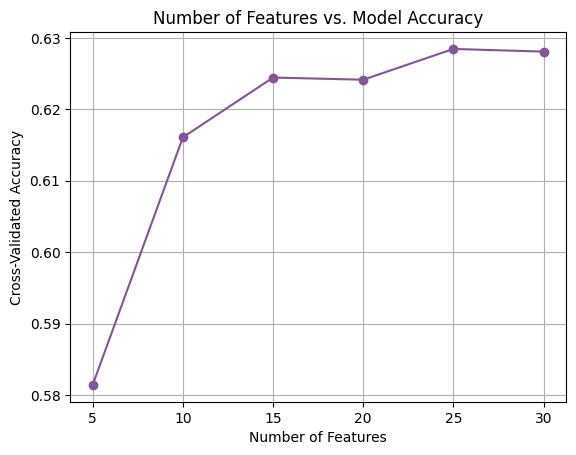

In [ ]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

feature_counts = [5, 10, 15, 20, 25, 30]
scores = []

for count in feature_counts:
    # Select top 'count' features using RFE
    selector = RFE(estimator, n_features_to_select=count, step=5)
    selector.fit(X, y_binary)

    # Test accuracy using Cross-Validation
    X_selected = X.iloc[:, selector.support_]
    score = cross_val_score(estimator, X_selected, y_binary, cv=5).mean()
    scores.append(score)
    print(f"Accuracy with {count} features: {score:.4f}")

# Plot the results to find the "Elbow"
plt.plot(feature_counts, scores, marker='o', color='#835496')
plt.title("Number of Features vs. Model Accuracy")
plt.xlabel("Number of Features")
plt.ylabel("Cross-Validated Accuracy")
plt.grid(True)
plt.show()

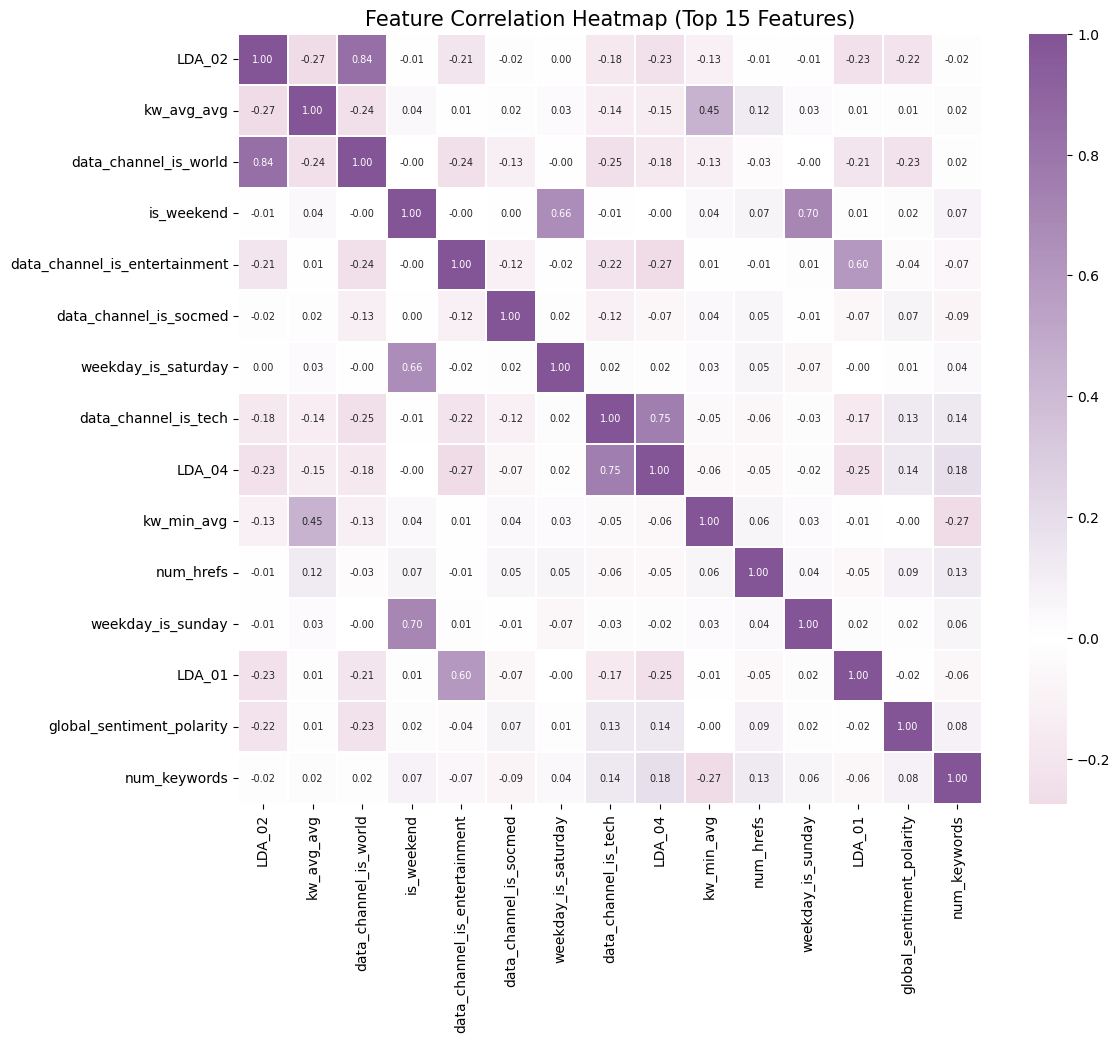

In [ ]:
# 1. Prepare the data: Ensure columns are clean and merged
X.columns = X.columns.str.strip()
y.columns = y.columns.str.strip()

# Combine X and the binary label for correlation calculation
# (Assumes you already created 'y_binary' as shown in previous steps)
temp_df = X.copy()
temp_df['label'] = y_binary

# 2. Identify top 15 features correlated with the label
# We use .corrwith() to compare all features in X against the label
label_corr = X.corrwith(temp_df["label"]).abs().nlargest(15)
top15_features = label_corr.index.tolist()

# 3. Create the Heatmap
# Define colors (you can replace these with your PALETTE variables)
colors = ["#C781A8", "#FFFFFF", "#835496"] # Pink to White to Purple
cmap = LinearSegmentedColormap.from_list("custom", colors)

plt.figure(figsize=(12, 10))
# Calculate correlation matrix for only the top 15 features
sub_corr = X[top15_features].corr()

sns.heatmap(sub_corr,
            cmap=cmap,
            center=0,
            linewidths=0.3,
            annot=True,     # Set to True if you want to see the numbers
            fmt=".2f",      # Rounds numbers to 2 decimal places
            annot_kws={"size": 7})

plt.title("Feature Correlation Heatmap (Top 15 Features)", fontsize=15)
plt.show()

In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

def perform_adf_test(data, feature_name):
    """
    Performs ADF test and prints interpreted results.
    """
    print(f"--- ADF Test for: {feature_name} ---")
    # We drop NaNs to ensure the test runs smoothly
    series = data[feature_name].dropna()

    result = adfuller(series)

    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')

    # Interpretation
    if result[1] <= 0.05:
        print("Result: Stationary (Reject Null Hypothesis - No Unit Root)")
    else:
        print("Result: Non-Stationary (Fail to Reject Null Hypothesis - Has Unit Root)")
    print("\n")

# Testing a subset of relevant features from your 'X' dataframe
features_to_check = ['n_tokens_title', 'global_sentiment_polarity', 'n_unique_tokens']

for feat in features_to_check:
    perform_adf_test(X, feat)

--- ADF Test for: n_tokens_title ---
ADF Statistic: -12.3218
p-value: 0.0000
Critical Values:
	1%: -3.4305
	5%: -2.8616
	10%: -2.5668
Result: Stationary (Reject Null Hypothesis - No Unit Root)


--- ADF Test for: global_sentiment_polarity ---
ADF Statistic: -16.4412
p-value: 0.0000
Critical Values:
	1%: -3.4305
	5%: -2.8616
	10%: -2.5668
Result: Stationary (Reject Null Hypothesis - No Unit Root)


--- ADF Test for: n_unique_tokens ---
ADF Statistic: -199.1445
p-value: 0.0000
Critical Values:
	1%: -3.4305
	5%: -2.8616
	10%: -2.5668
Result: Stationary (Reject Null Hypothesis - No Unit Root)


